In [59]:
# ==========================================================
# Import Libraries
# ==========================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

# ==========================================================
# Load Feature Engineered Data
# ==========================================================

processed_dir = Path("data/processed")

sales_fe = pd.read_csv(
    processed_dir / "sales_fe.csv",
    parse_dates=["date"]
)

future_fe = pd.read_csv(
    processed_dir / "future_fe.csv",
    parse_dates=["date"]
)

print("=" * 60)
print("FEATURE DATA LOADED")
print("=" * 60)

print(f"Training : {sales_fe.shape}")
print(f"Future   : {future_fe.shape}")

FEATURE DATA LOADED
Training : (624624, 61)
Future   : (40560, 61)


In [60]:
# ==========================================================
# Prepare Modelling Dataset
# ==========================================================

target = "sales"

drop_columns = [
    "sales",
    "date"
]

feature_columns = [
    col
    for col in sales_fe.columns
    if col not in drop_columns
]

print("=" * 60)
print("FEATURE PREPARATION")
print("=" * 60)

print(f"Target Variable : {target}")
print(f"Number of Features : {len(feature_columns)}")

FEATURE PREPARATION
Target Variable : sales
Number of Features : 59


In [61]:
# ==========================================================
# Train / Validation Split
# ==========================================================

forecast_horizon = 42

cutoff_date = (
    sales_fe["date"].max()
    - pd.Timedelta(days=forecast_horizon - 1)
)

train_df = sales_fe[
    sales_fe["date"] < cutoff_date
].copy()

valid_df = sales_fe[
    sales_fe["date"] >= cutoff_date
].copy()

print("=" * 60)
print("TRAIN / VALIDATION SPLIT")
print("=" * 60)

print("Training observations :", len(train_df))
print("Validation observations:", len(valid_df))

print("\nTraining Period")
print(train_df["date"].min(), "to", train_df["date"].max())

print("\nValidation Period")
print(valid_df["date"].min(), "to", valid_df["date"].max())

TRAIN / VALIDATION SPLIT
Training observations : 596232
Validation observations: 28392

Training Period
2013-01-07 00:00:00 to 2015-06-07 00:00:00

Validation Period
2015-06-08 00:00:00 to 2015-07-19 00:00:00


In [63]:
# ==========================================================
# Check Missing Values
# ==========================================================

print("=" * 60)
print("MISSING VALUES BEFORE MODEL")
print("=" * 60)

print("\nTraining Data")
print(
    train_df.isna()
    .sum()
    .sort_values(ascending=False)
)

print("\nValidation Data")
print(
    valid_df.isna()
    .sum()
    .sort_values(ascending=False)
)

print("\nFuture Data")
print(
    future_fe.isna()
    .sum()
    .sort_values(ascending=False)
)

MISSING VALUES BEFORE MODEL

Training Data
rolling_min_28       18928
rolling_median_28    18928
rolling_std_28       18928
rolling_mean_28      18928
rolling_max_28       18928
                     ...  
day_of_month             0
is_weekend               0
is_month_start           0
is_month_end             0
state_holiday_c          0
Length: 61, dtype: int64

Validation Data
store_id             0
rolling_mean_28      0
rolling_median_7     0
rolling_median_14    0
rolling_median_21    0
                    ..
rolling_mean_7       0
rolling_std_7        0
rolling_mean_14      0
rolling_std_14       0
state_holiday_c      0
Length: 61, dtype: int64

Future Data
customers            40560
store_id                 0
promo_mean_14            0
rolling_median_7         0
rolling_median_14        0
                     ...  
rolling_mean_7           0
rolling_std_7            0
rolling_mean_14          0
rolling_std_14           0
state_holiday_c          0
Length: 61, dtype: int64


In [64]:
# ==========================================================
# Remove Missing Values
# ==========================================================

rows_before = len(train_df)

train_df = train_df.dropna().reset_index(drop=True)

rows_after = len(train_df)

print("=" * 60)
print("REMOVE MISSING VALUES")
print("=" * 60)

print(f"Rows before : {rows_before:,}")
print(f"Rows after  : {rows_after:,}")
print(f"Rows removed: {rows_before - rows_after:,}")

REMOVE MISSING VALUES
Rows before : 596,232
Rows after  : 577,304
Rows removed: 18,928


In [65]:
# ==========================================================
# Prepare Model Inputs
# ==========================================================

target = "sales"

drop_columns = [
    "sales",
    "date",
    "store_id",         #why delete this？ exlain
    "customers"
]

X_train = train_df.drop(columns=drop_columns)
y_train = train_df[target]

X_valid = valid_df.drop(columns=drop_columns)
y_valid = valid_df[target]

print("=" * 60)
print("MODEL MATRICES")
print("=" * 60)

print("X_train :", X_train.shape)
print("y_train :", y_train.shape)

print("\nX_valid :", X_valid.shape)
print("y_valid :", y_valid.shape)

MODEL MATRICES
X_train : (577304, 57)
y_train : (577304,)

X_valid : (28392, 57)
y_valid : (28392,)


In [66]:
print("=" * 60)
print("FEATURE DATA TYPES")
print("=" * 60)

print(X_train.dtypes.value_counts())

object_cols = X_train.select_dtypes(include="object").columns.tolist()

print("\nObject columns:")
print(object_cols)

FEATURE DATA TYPES
float64    30
int64      27
Name: count, dtype: int64

Object columns:
[]


In [67]:
# ==========================================================
# Train Global Random Forest
# ==========================================================

from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    max_features="sqrt",
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)

print("=" * 60)
print("TRAIN GLOBAL RANDOM FOREST")
print("=" * 60)

rf.fit(X_train, y_train)

print("Training completed.")

TRAIN GLOBAL RANDOM FOREST
Training completed.


In [68]:
# ==========================================================
# Validation Prediction
# ==========================================================

y_pred = rf.predict(X_valid)

print("=" * 60)
print("PREDICTION COMPLETED")
print("=" * 60)

print("Prediction length:", len(y_pred))

PREDICTION COMPLETED
Prediction length: 28392


                    MAE       MAPE  Stores
store_type                                
A           2099.646922  31.283029     364
B           1809.870485  33.005733      11
C           2060.269078  31.177569      75
D           2239.572077  31.321910     206


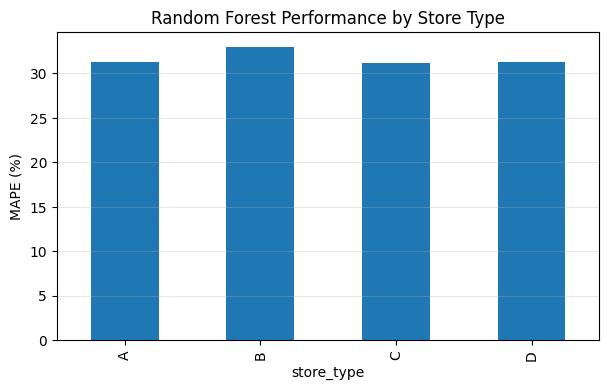

In [91]:
# Save validation results
valid_result = valid_df.copy()

valid_result["prediction"] = y_pred

valid_result["abs_error"] = np.abs(
    valid_result["sales"] -
    valid_result["prediction"]
)

valid_result["ape"] = (
    np.abs(
        valid_result["sales"] -
        valid_result["prediction"]
    )
    /
    valid_result["sales"]
) * 100

valid_result = valid_result[
    valid_result["sales"] != 0
]

valid_result["store_type"] = np.select(
    [
        valid_result["store_type_a"] == 1,
        valid_result["store_type_b"] == 1,
        valid_result["store_type_c"] == 1,
        valid_result["store_type_d"] == 1,
    ],

    [
        "A",
        "B",
        "C",
        "D"
    ]

)

rf_storetype = (
    valid_result
    .groupby("store_type")
    .agg(
        MAE=("abs_error","mean"),
        MAPE=("ape","mean"),
        Stores=("store_id","nunique")
    )

)

print(rf_storetype)

plt.figure(figsize=(7,4))

rf_storetype["MAPE"].plot(
    kind="bar"
)

plt.ylabel("MAPE (%)")

plt.title("Random Forest Performance by Store Type")

plt.grid(axis="y", alpha=0.3)

plt.show()

In [69]:
# ==========================================================
# Model Evaluation
# ==========================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

import numpy as np

mae = mean_absolute_error(y_valid, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_valid, y_pred)
)

mape = (
    np.abs((y_valid - y_pred) / y_valid)
)

mape = mape[y_valid != 0].mean() * 100

print("=" * 60)
print("RANDOM FOREST PERFORMANCE")
print("=" * 60)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}%")

RANDOM FOREST PERFORMANCE
MAE  : 2602.70
RMSE : 3512.78
MAPE : 31.31%


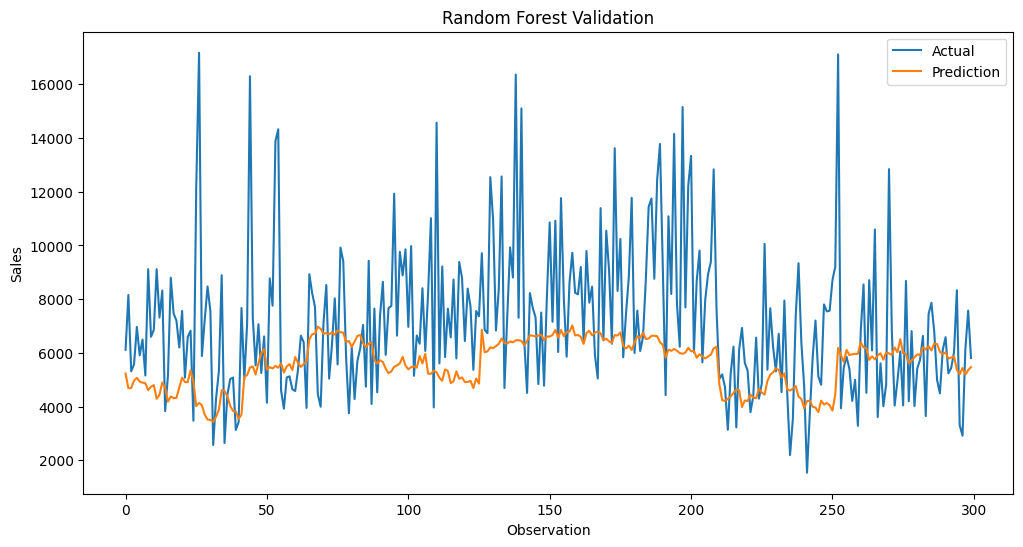

In [70]:
# ==========================================================
# Prediction vs Actual
# ==========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    y_valid.values[:300],
    label="Actual"
)

plt.plot(
    y_pred[:300],
    label="Prediction"
)

plt.legend()

plt.title("Random Forest Validation")

plt.xlabel("Observation")

plt.ylabel("Sales")

plt.show()

In [71]:
# ==========================================================
# Feature Importance
# ==========================================================

import pandas as pd

feature_importance = pd.DataFrame({

    "Feature": X_train.columns,
    "Importance": rf.feature_importances_

})

feature_importance = feature_importance.sort_values(

    "Importance",
    ascending=False

).reset_index(drop=True)

print("=" * 60)
print("FEATURE IMPORTANCE")
print("=" * 60)

print(feature_importance)

FEATURE IMPORTANCE
                 Feature  Importance
0   competition_distance    0.179400
1         rolling_max_28    0.056786
2      rolling_median_28    0.048125
3        rolling_mean_28    0.047164
4         rolling_max_21    0.046346
5         rolling_max_14    0.042168
6         rolling_std_28    0.041190
7      rolling_median_21    0.037898
8      rolling_median_14    0.036275
9        rolling_mean_14    0.033457
10       rolling_mean_21    0.033349
11        rolling_std_14    0.031692
12        rolling_std_21    0.030609
13          week_of_year    0.027046
14         rolling_max_7    0.026944
15      rolling_median_7    0.025519
16                  year    0.024738
17         rolling_std_7    0.023079
18        rolling_mean_7    0.021746
19                 month    0.017882
20                lag_28    0.016225
21                 lag_1    0.015750
22                lag_21    0.015660
23                lag_14    0.015326
24          day_of_month    0.015108
25                 

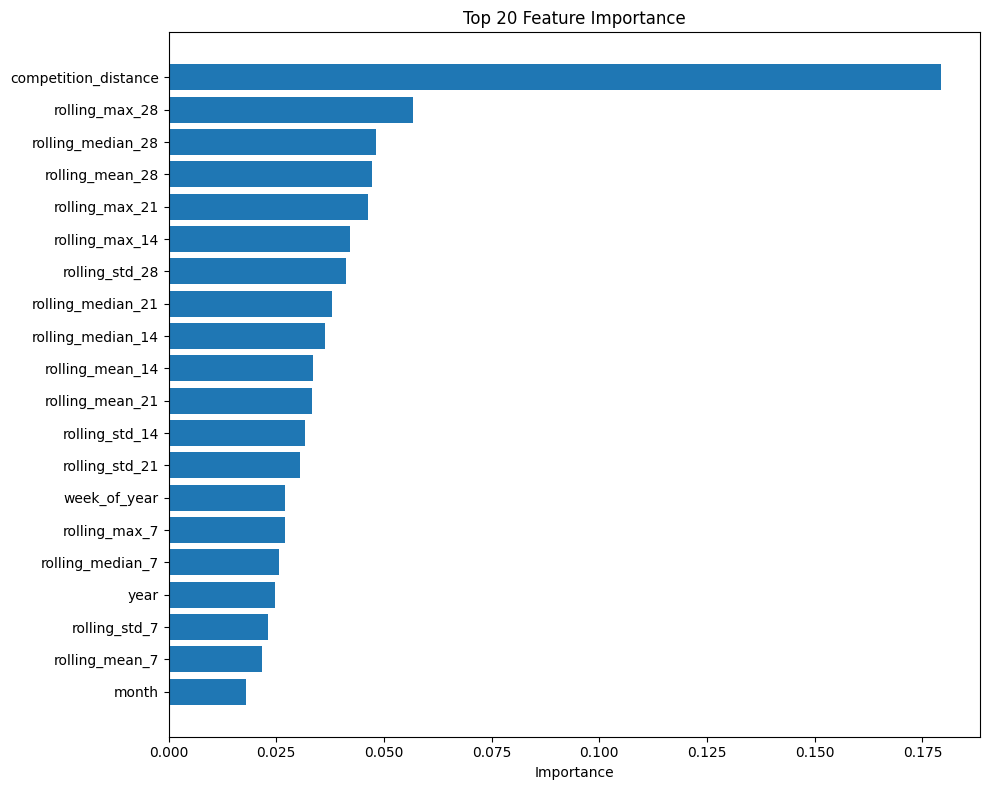

In [72]:
# ==========================================================
# Plot Feature Importance
# ==========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

plt.barh(

    feature_importance["Feature"][:20][::-1],
    feature_importance["Importance"][:20][::-1]

)

plt.title("Top 20 Feature Importance")

plt.xlabel("Importance")

plt.tight_layout()

plt.show()

In [73]:
print(X_train.columns.tolist())

['open', 'promo', 'school_holiday', 'competition_distance', 'year', 'month', 'quarter', 'week_of_year', 'day_of_week', 'day_of_month', 'is_weekend', 'is_month_start', 'is_month_end', 'is_quarter_end', 'lag_1', 'lag_7', 'lag_14', 'lag_21', 'lag_28', 'promo_lag_1', 'promo_lag_7', 'rolling_mean_7', 'rolling_std_7', 'rolling_mean_14', 'rolling_std_14', 'rolling_mean_21', 'rolling_std_21', 'rolling_mean_28', 'rolling_std_28', 'rolling_median_7', 'rolling_median_14', 'rolling_median_21', 'rolling_median_28', 'rolling_max_7', 'rolling_min_7', 'rolling_max_14', 'rolling_min_14', 'rolling_max_21', 'rolling_min_21', 'rolling_max_28', 'rolling_min_28', 'promo_mean_7', 'promo_mean_14', 'promo_weekend', 'promo_schoolholiday', 'promo_stateholiday', 'store_type_a', 'store_type_b', 'store_type_c', 'store_type_d', 'assortment_a', 'assortment_b', 'assortment_c', 'state_holiday_0', 'state_holiday_a', 'state_holiday_b', 'state_holiday_c']


In [92]:
# ==========================================================
# Hyperparameter Tuning using Rolling Forecast Origin CV
# ==========================================================

print("=" * 60)
print("HYPERPARAMETER TUNING WITH ROLLING CV")
print("=" * 60)

parameter_list = [

    {
        "n_estimators": 200,
        "max_features": "sqrt",
        "min_samples_leaf": 10
    },

    {
        "n_estimators": 300,
        "max_features": "sqrt",
        "min_samples_leaf": 10
    },

    {
        "n_estimators": 500,
        "max_features": "sqrt",
        "min_samples_leaf": 10
    },

    {
        "n_estimators": 300,
        "max_features": "sqrt",
        "min_samples_leaf": 5
    }

]

# Rolling CV settings
n_folds = 3
forecast_horizon = 42

all_dates = np.sort(train_df["date"].unique())

results = []

best_mape = np.inf
best_params = None

for i, params in enumerate(parameter_list, start=1):

    print(f"\nEvaluating Model {i}/{len(parameter_list)}")

    fold_mae = []
    fold_rmse = []
    fold_mape = []

    for fold in range(n_folds):
        valid_end = len(all_dates) - fold * forecast_horizon
        valid_start = valid_end - forecast_horizon

        valid_dates = all_dates[valid_start:valid_end]
        train_dates = all_dates[:valid_start]

        train_fold = train_df[
            train_df["date"].isin(train_dates)
        ].copy()

        valid_fold = train_df[
            train_df["date"].isin(valid_dates)
        ].copy()

        X_tr = train_fold.drop(columns=drop_columns)
        y_tr = train_fold[target]

        X_va = valid_fold.drop(columns=drop_columns)
        y_va = valid_fold[target]

        rf = RandomForestRegressor(

            random_state=42,
            n_jobs=-1,
            **params

        )

        rf.fit(X_tr, y_tr)

        pred = rf.predict(X_va)

        mae = mean_absolute_error(
            y_va,
            pred
        )

        rmse = np.sqrt(
            mean_squared_error(
                y_va,
                pred
            )
        )

        mask = y_va != 0

        mape = (
                np.abs(
                    (
                            y_va[mask] - pred[mask]
                    )
                    /
                    y_va[mask]
                ).mean()
                * 100
        )

        fold_mae.append(mae)
        fold_rmse.append(rmse)
        fold_mape.append(mape)

    avg_mae = np.mean(fold_mae)
    avg_rmse = np.mean(fold_rmse)
    avg_mape = np.mean(fold_mape)

    results.append({

        "n_estimators": params["n_estimators"],
        "max_features": params["max_features"],
        "min_samples_leaf": params["min_samples_leaf"],
        "CV_MAE": avg_mae,
        "CV_RMSE": avg_rmse,
        "CV_MAPE": avg_mape

    })

    if avg_mape < best_mape:
        best_mape = avg_mape
        best_params = params

results = (
    pd.DataFrame(results)
    .sort_values("CV_MAPE")
    .reset_index(drop=True)
)

print("\n")
print("=" * 60)
print("TUNING RESULTS")
print("=" * 60)

print(results)

print("\nBest Parameters")
print(best_params)

print(f"\nBest CV MAPE : {best_mape:.2f}%")

HYPERPARAMETER TUNING WITH ROLLING CV

Evaluating Model 1/4

Evaluating Model 2/4

Evaluating Model 3/4

Evaluating Model 4/4


TUNING RESULTS
   n_estimators max_features  min_samples_leaf       CV_MAE      CV_RMSE  \
0           500         sqrt                10  2651.934627  3547.185605   
1           300         sqrt                10  2652.663373  3548.273127   
2           200         sqrt                10  2652.501397  3548.581952   
3           300         sqrt                 5  2639.922408  3530.400923   

     CV_MAPE  
0  31.464905  
1  31.487314  
2  31.489932  
3  31.576795  

Best Parameters
{'n_estimators': 500, 'max_features': 'sqrt', 'min_samples_leaf': 10}

Best CV MAPE : 31.46%


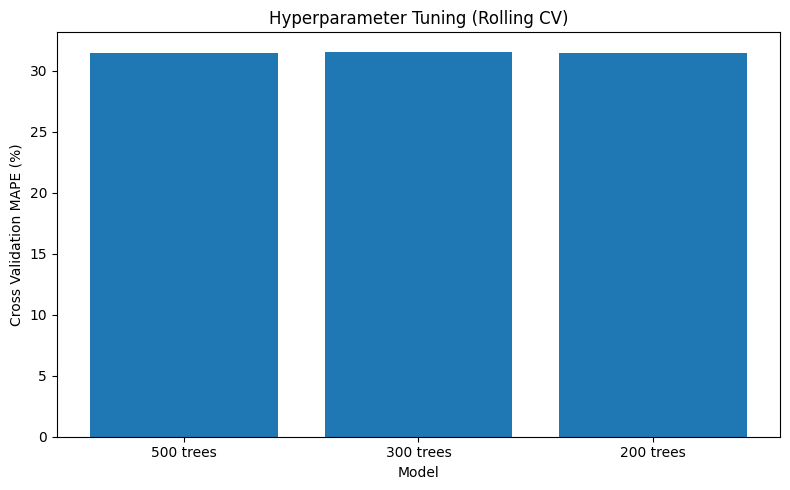

In [93]:
plt.figure(figsize=(8,5))

labels = (
    results["n_estimators"].astype(str)
    + " trees"
)

plt.bar(
    labels,
    results["CV_MAPE"]
)

plt.title("Hyperparameter Tuning (Rolling CV)")

plt.xlabel("Model")

plt.ylabel("Cross Validation MAPE (%)")

plt.tight_layout()

plt.show()

In [94]:
# ==========================================================
# Train Final Random Forest on Full Historical Data
# ==========================================================

print("=" * 60)
print("TRAIN FINAL RANDOM FOREST")
print("=" * 60)

# Use all available historical data
full_df = sales_fe.dropna().copy()

X_full = full_df.drop(columns=drop_columns)
y_full = full_df[target]

# Train final model
final_rf = RandomForestRegressor(
    **best_params,
    random_state=42,
    n_jobs=-1
)

final_rf.fit(X_full, y_full)

print("Final model training completed.")

print(f"Training observations : {len(full_df):,}")
print(f"Number of features    : {X_full.shape[1]}")

TRAIN FINAL RANDOM FOREST
Final model training completed.
Training observations : 605,696
Number of features    : 57


In [95]:
from sklearn.inspection import permutation_importance

# ==========================================================
# Permutation Feature Importance
# ==========================================================

perm_importance = permutation_importance(
    final_rf,
    X_valid,
    y_valid,
    n_repeats=10,
    random_state=42,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

perm_df = pd.DataFrame({
    "Feature": X_valid.columns,
    "Importance": perm_importance.importances_mean
})

perm_df = perm_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

print(perm_df.head(20))

                 Feature  Importance
0   competition_distance  585.404663
1         rolling_max_28  338.901863
2      rolling_median_28  301.692138
3        rolling_mean_28  301.172977
4         rolling_max_21  280.668584
5         rolling_max_14  246.428993
6      rolling_median_21  217.976057
7           store_type_d  217.464443
8         rolling_std_28  212.255951
9           store_type_a  211.738942
10     rolling_median_14  210.290812
11       rolling_mean_14  199.110870
12       rolling_mean_21  193.156458
13          assortment_a  186.896169
14          assortment_c  178.315340
15        rolling_std_14  152.339505
16        rolling_std_21  148.840159
17         rolling_max_7  115.141046
18      rolling_median_7  103.100748
19        rolling_mean_7   94.601071


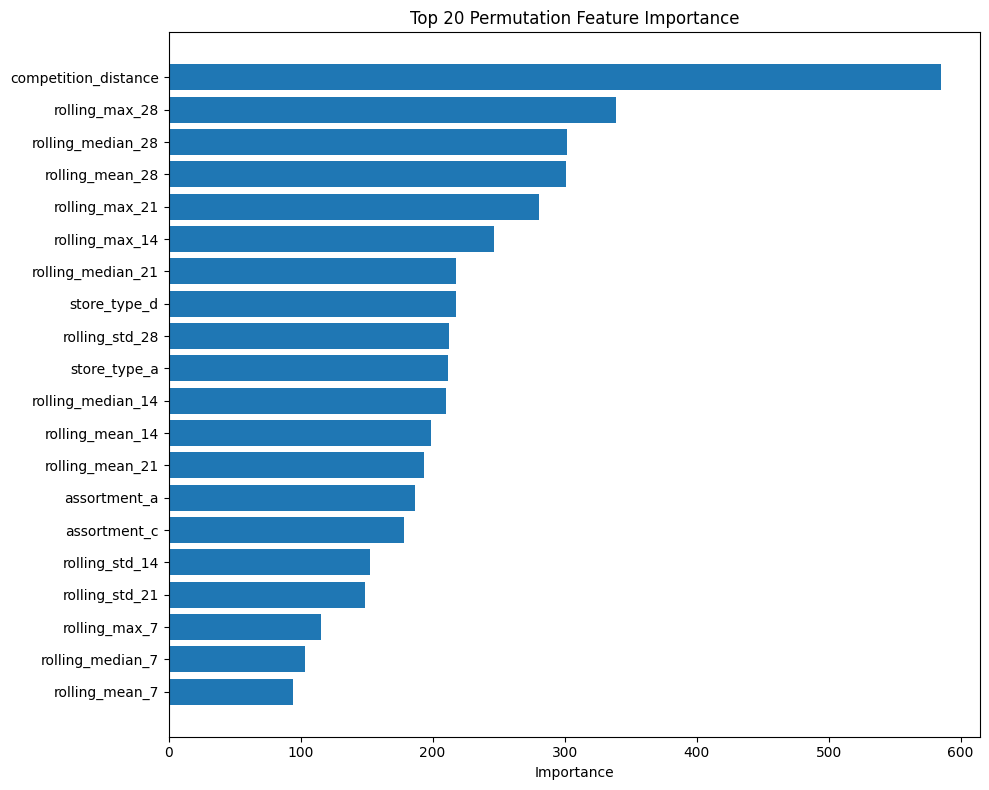

In [96]:
plt.figure(figsize=(10,8))

plt.barh(
    perm_df["Feature"][:20][::-1],
    perm_df["Importance"][:20][::-1]
)

plt.title("Top 20 Permutation Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [97]:
print(future_fe.columns.tolist())

['store_id', 'date', 'sales', 'customers', 'open', 'promo', 'school_holiday', 'competition_distance', 'year', 'month', 'quarter', 'week_of_year', 'day_of_week', 'day_of_month', 'is_weekend', 'is_month_start', 'is_month_end', 'is_quarter_end', 'lag_1', 'lag_7', 'lag_14', 'lag_21', 'lag_28', 'promo_lag_1', 'promo_lag_7', 'rolling_mean_7', 'rolling_std_7', 'rolling_mean_14', 'rolling_std_14', 'rolling_mean_21', 'rolling_std_21', 'rolling_mean_28', 'rolling_std_28', 'rolling_median_7', 'rolling_median_14', 'rolling_median_21', 'rolling_median_28', 'rolling_max_7', 'rolling_min_7', 'rolling_max_14', 'rolling_min_14', 'rolling_max_21', 'rolling_min_21', 'rolling_max_28', 'rolling_min_28', 'promo_mean_7', 'promo_mean_14', 'promo_weekend', 'promo_schoolholiday', 'promo_stateholiday', 'store_type_a', 'store_type_b', 'store_type_c', 'store_type_d', 'assortment_a', 'assortment_b', 'assortment_c', 'state_holiday_0', 'state_holiday_a', 'state_holiday_b', 'state_holiday_c']


In [98]:
# ==========================================================
# Prepare Future Features
# ==========================================================

future_X = future_fe.drop(
    columns=drop_columns
)

print("=" * 60)
print("CHECK FUTURE FEATURES")
print("=" * 60)

print("Training shape :", X_full.shape)
print("Future shape   :", future_X.shape)

print("\nFeature names identical:")
print(X_full.columns.equals(future_X.columns))

CHECK FUTURE FEATURES
Training shape : (605696, 57)
Future shape   : (40560, 57)

Feature names identical:
True


In [99]:
# ==========================================================
# Predict Future Sales
# ==========================================================

future_pred = final_rf.predict(future_X)

future_result = future_fe.copy()

future_result["sales_prediction"] = future_pred

print("=" * 60)
print("FUTURE PREDICTION")
print("=" * 60)

print(future_result[
          [
              "store_id",
              "date",
              "sales_prediction"
          ]
      ].head())

print("\nPrediction Summary")

print(future_result["sales_prediction"].describe())

FUTURE PREDICTION
   store_id       date  sales_prediction
0         1 2015-09-17       3823.649494
1         2 2015-09-17       6868.385142
2         3 2015-09-17       6457.089102
3         4 2015-09-17       6545.103063
4         5 2015-09-17       6758.129058

Prediction Summary
count    40560.000000
mean      5795.178551
std       1269.204964
min       1096.510652
25%       5245.737544
50%       5919.494439
75%       6524.389595
max      11085.068589
Name: sales_prediction, dtype: float64


In [102]:
# ==========================================================
# Save Prediction
# ==========================================================

future_result.to_csv(
    processed_dir / "future_prediction_rf.csv",
    index=False
)

print("Prediction file saved successfully.")

Prediction file saved successfully.


In [ ]:

#Weekly  Aggregation
# ==========================================================
# Create Forecast Week
# ==========================================================

future_result = future_result.sort_values(
    ["date", "store_id"]
).reset_index(drop=True)

forecast_start = future_result["date"].min()

future_result["forecast_week"] = (
                                         (future_result["date"] - forecast_start).dt.days // 7
                                 ) + 1

print("=" * 60)
print("FORECAST WEEKS")
print("=" * 60)

print(future_result["forecast_week"].value_counts().sort_index())

In [ ]:
# ==========================================================
# Weekly Forecast by Store
# ==========================================================

store_weekly = (
    future_result
    .groupby(
        ["store_id", "forecast_week"],
        as_index=False
    )["sales_prediction"]
    .sum()
)

print("=" * 60)
print("STORE WEEKLY FORECAST")
print("=" * 60)

print(store_weekly.head())

store_weekly.to_csv(
    processed_dir / "store_weekly_forecast.csv",
    index=False
)

In [ ]:
# ==========================================================
# Recover Store Type
# ==========================================================

future_result["store_type"] = np.select(
    [
        future_result["store_type_a"] == 1,
        future_result["store_type_b"] == 1,
        future_result["store_type_c"] == 1,
        future_result["store_type_d"] == 1
    ],
    [
        "A",
        "B",
        "C",
        "D"
    ]
)

In [ ]:
# ==========================================================
# Weekly Forecast by Store Type
# ==========================================================

storetype_weekly = (
    future_result
    .groupby(
        ["store_type", "forecast_week"],
        as_index=False
    )["sales_prediction"]
    .sum()
)

print(storetype_weekly)

storetype_weekly.to_csv(
    processed_dir / "storetype_weekly_forecast.csv",
    index=False
)

In [ ]:
# ==========================================================
# Weekly Forecast for Company
# ==========================================================

company_weekly = (
    future_result
    .groupby(
        "forecast_week",
        as_index=False
    )["sales_prediction"]
    .sum()
)

print(company_weekly)

company_weekly.to_csv(
    processed_dir / "company_weekly_forecast.csv",
    index=False
)

In [ ]:
# ==========================================================
# Total Forecast over Next 6 Weeks
# ==========================================================

total_sales = future_result["sales_prediction"].sum()

print("=" * 60)
print("TOTAL SALES OVER NEXT 6 WEEKS")
print("=" * 60)

print(f"{total_sales:,.2f}")